# Buoc 1: Load du lieu

In [1]:
def loaddata(symbol, from_date, to_date):
    # Import necessary modules
    from ssi_fc_data import fc_md_client, model
    import pandas as pd  # Import Pandas for DataFrame handling
    import json
    import configDataSSI

    # Create a Market Data Client
    # from_date = "01/11/2023"
    # to_date = "17/11/2023"
    client = fc_md_client.MarketDataClient(configDataSSI)

    req = model.daily_ohlc(symbol, from_date, to_date) # Viet lai lay tu yfinance

    data_dict = client.daily_ohlc(configDataSSI, req)
    # print(type(data_dict))
    # Access the list of dictionaries in the "data" field
    data_list = data_dict['data']
    print(data_list)
    # Convert the list of dictionaries into a DataFrame
    data = pd.DataFrame(data_list)

    # Print or work with the DataFrame
    # print(data)
    return data

In [2]:
data = loaddata('ACB','01/06/2024', '14/08/2024')

[{'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '03/06/2024', 'Time': None, 'Open': '24850', 'High': '24950', 'Low': '24600', 'Close': '24800', 'Volume': '16242700', 'Value': '401796470000.0040'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '04/06/2024', 'Time': None, 'Open': '24800', 'High': '24800', 'Low': '24450', 'Close': '24500', 'Volume': '9722200', 'Value': '239436744999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '05/06/2024', 'Time': None, 'Open': '24750', 'High': '24750', 'Low': '24300', 'Close': '24350', 'Volume': '10785200', 'Value': '264021520000.0040'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '06/06/2024', 'Time': None, 'Open': '24400', 'High': '24500', 'Low': '24300', 'Close': '24350', 'Volume': '8027700', 'Value': '195620314999.9970'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '07/06/2024', 'Time': None, 'Open': '24550', 'High': '24650', 'Low': '24300', 'Close': '24600', 'Volume': '5887100', 'Value': '143893645000.0010'}, {'

In [3]:
data

,Symbol,Market,TradingDate,Time,Open,High,Low,Close,Volume,Value
0,ACB,HOSE,03/06/2024,None,24850,24950,24600,24800,16242700,401796470000.0040
1,ACB,HOSE,04/06/2024,None,24800,24800,24450,24500,9722200,239436744999.9990
2,ACB,HOSE,05/06/2024,None,24750,24750,24300,24350,10785200,264021520000.0040
3,ACB,HOSE,06/06/2024,None,24400,24500,24300,24350,8027700,195620314999.9970
4,ACB,HOSE,07/06/2024,None,24550,24650,24300,24600,5887100,143893645000.0010
5,ACB,HOSE,10/06/2024,None,24600,24700,24300,24400,7670900,187546199999.9990
6,ACB,HOSE,11/06/2024,None,24400,24450,24100,24150,9200500,222930730000.0020
7,ACB,HOSE,12/06/2024,None,24150,24550,23900,24550,10388900,250963980000.0010
8,ACB,HOSE,13/06/2024,None,24550,24900,24400,24800,11713500,288627040000.0010
9,ACB,HOSE,14/06/2024,None,24700,24900,24600,24600,11038000,273258660000.0030


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Symbol       53 non-null     object
 1   Market       53 non-null     object
 2   TradingDate  53 non-null     object
 3   Time         0 non-null      object
 4   Open         53 non-null     object
 5   High         53 non-null     object
 6   Low          53 non-null     object
 7   Close        53 non-null     object
 8   Volume       53 non-null     object
 9   Value        53 non-null     object
dtypes: object(10)
memory usage: 4.3+ KB


# Parse

In [5]:
import pandas as pd
data['TradingDate'] = pd.to_datetime(data['TradingDate'], dayfirst=True)
data.set_index('TradingDate', inplace=True)
# Giả sử 'data' là DataFrame của bạn với dữ liệu lịch sử giá cổ phiếu
data['Open'] = pd.to_numeric(data['Open'], errors='coerce')
data['High'] = pd.to_numeric(data['High'], errors='coerce')
data['Low'] = pd.to_numeric(data['Low'], errors='coerce')
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')
data['Volume'] = pd.to_numeric(data['Volume'], errors='coerce')

data

,Symbol,Market,Time,Open,High,Low,Close,Volume,Value
TradingDate,,,,,,,,,
2024-06-03,ACB,HOSE,None,24850,24950,24600,24800,16242700,401796470000.0040
2024-06-04,ACB,HOSE,None,24800,24800,24450,24500,9722200,239436744999.9990
2024-06-05,ACB,HOSE,None,24750,24750,24300,24350,10785200,264021520000.0040
2024-06-06,ACB,HOSE,None,24400,24500,24300,24350,8027700,195620314999.9970
2024-06-07,ACB,HOSE,None,24550,24650,24300,24600,5887100,143893645000.0010
2024-06-10,ACB,HOSE,None,24600,24700,24300,24400,7670900,187546199999.9990
2024-06-11,ACB,HOSE,None,24400,24450,24100,24150,9200500,222930730000.0020
2024-06-12,ACB,HOSE,None,24150,24550,23900,24550,10388900,250963980000.0010
2024-06-13,ACB,HOSE,None,24550,24900,24400,24800,11713500,288627040000.0010


# Buoc 2: Viet 3 ham kiem tra du lieu

In [6]:
def kiemtratinhieu(data, from_date, to_date):
    import pandas as pd
    # data o tren

    data['TradingDate'] = pd.to_datetime(data['TradingDate'], dayfirst=True)
    data.set_index('TradingDate', inplace=True)
    # Giả sử 'data' là DataFrame của bạn với dữ liệu lịch sử giá cổ phiếu
    data['Open'] = pd.to_numeric(data['Open'], errors='coerce')
    data['High'] = pd.to_numeric(data['High'], errors='coerce')
    data['Low'] = pd.to_numeric(data['Low'], errors='coerce')
    data['Close'] = pd.to_numeric(data['Close'], errors='coerce')
    data['Volume'] = pd.to_numeric(data['Volume'], errors='coerce')

    # Định nghĩa hàm để kiểm tra nến Doji chân dài
    def is_long_legged_doji(row):
        body_range = abs(row['Close'] - row['Open']) # Doji khong phan biet Open > Close hay Close > Open
        upper_shadow = row['High'] - max(row['Open'], row['Close'])
        lower_shadow = min(row['Open'], row['Close']) - row['Low']
        # Điều chỉnh ngưỡng này theo dữ liệu cụ thể của bạn
        doji_threshold = 0.1 / 100 * row['Close']
        return body_range <= doji_threshold and upper_shadow >= 2 * body_range and lower_shadow >= 2 * body_range

    # Định nghĩa hàm để kiểm tra nến tăng
    def is_bullish_candle(current_row, previous_row):
        return (current_row['Close'] > current_row['Open'] and
                current_row['Close'] > previous_row['Close'] and
                previous_row['Close'] <= previous_row['Open'])

    # Định nghĩa hàm để kiểm tra nến giảm
    def is_bearish_candle(current_row, previous_row):
        return (current_row['Close'] < current_row['Open'] and
                current_row['Close'] < previous_row['Close'] and
                previous_row['Close'] >= previous_row['Open'])

    # Lặp qua DataFrame 2 record cuối cùng để kiểm tra chiến lược mua
    buy_signals = []
    sell_signals = []

    for i in range(0, len(data)): # Chi lay 2 nen
        current_row = data.iloc[i]
        previous_row = data.iloc[i - 1]
        
        # Kiểm tra nến hiện tại có phải là nến tăng và nếu nến trước đó là nến Doji chân dài
        if is_bullish_candle(current_row, previous_row) and is_long_legged_doji(previous_row):
            # Nếu thỏa mãn cả ba điều kiện, thêm ngày vào danh sách tín hiệu mua
            buy_signals.append(current_row.name)  # .name sẽ lấy chỉ số (ngày) của hàng
        if is_bearish_candle(current_row, previous_row) and is_long_legged_doji(previous_row):
            sell_signals.append(current_row.name)

    # In ra danh sách các tín hiệu mua
    print("Buy signals " + from_date + " to " + to_date + "on dates:", buy_signals)
    print("Sell signals on dates:", sell_signals)

# Buoc 3: Show nen len de xem

In [7]:
def showdata(data):
    import matplotlib.pyplot as plt
    import matplotlib.lines as mlines

    def draw_candlestick_with_labels(ax, data):
        # Sử dụng enumerate để nhận vị trí chỉ số và dữ liệu hàng
        for i, (index, row) in enumerate(data.iterrows()):
            # Xác định màu sắc dựa trên giá Open và Close
            color = 'green' if row['Open'] <= row['Close'] else 'red'
            
            # Vẽ bóng nến (High và Low)
            ax.plot([i, i], [row['Low'], row['High']], color='black')
            
            # Vẽ thân nến (Open và Close)
            body_height = max(row['Close'] - row['Open'], 0.01)  # Đảm bảo có chiều cao tối thiểu
            body_bottom = min(row['Close'], row['Open'])
            open_close_rect = plt.Rectangle((i - 0.2, body_bottom), 0.4, body_height, 
                                            facecolor=color, edgecolor='black')
            ax.add_patch(open_close_rect)
            
            # Thêm nhãn giá
            ax.text(i, row['High'], f"{row['High']}", va='bottom', ha='center', fontsize=8)
            ax.text(i, row['Low'], f"{row['Low']}", va='top', ha='center', fontsize=8)
            ax.text(i - 0.2, row['Open'], f"{row['Open']}", va='center', ha='right', fontsize=8)
            ax.text(i + 0.2, row['Close'], f"{row['Close']}", va='center', ha='left', fontsize=8)

    # Khởi tạo plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Vẽ các nến với nhãn từ DataFrame
    draw_candlestick_with_labels(ax, data)

    # Thiết lập giới hạn cho biểu đồ
    ax.set_xlim(-1, len(data))
    ax.set_ylim(data['Low'].min() * 0.95, data['High'].max() * 1.05)  # Đặt giới hạn với một chút đệm

    # Thiết lập nhãn cho trục x
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels([index.strftime('%Y-%m-%d') for index in data.index], rotation=45)
    ax.set_ylabel('Price')

    # Hiển thị plot
    plt.show()


# Auto Trade

[{'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '30/07/2024', 'Time': None, 'Open': '24000', 'High': '24150', 'Low': '23950', 'Close': '24150', 'Volume': '5489200', 'Value': '131998999999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '31/07/2024', 'Time': None, 'Open': '24200', 'High': '24550', 'Low': '24100', 'Close': '24550', 'Volume': '8548700', 'Value': '208478694999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '01/08/2024', 'Time': None, 'Open': '24500', 'High': '24600', 'Low': '23950', 'Close': '23950', 'Volume': '9174700', 'Value': '221875354999.9970'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '02/08/2024', 'Time': None, 'Open': '23900', 'High': '24000', 'Low': '23650', 'Close': '23950', 'Volume': '13706000', 'Value': '326483410000'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '05/08/2024', 'Time': None, 'Open': '23600', 'High': '23850', 'Low': '23150', 'Close': '23200', 'Volume': '20086500', 'Value': '471876965000.0060'}, {'Symbo

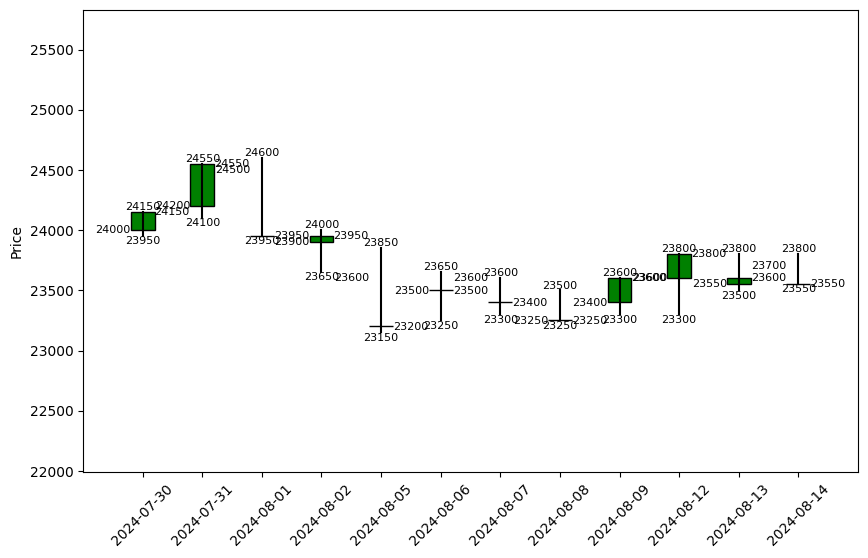

[{'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '30/07/2024', 'Time': None, 'Open': '24000', 'High': '24150', 'Low': '23950', 'Close': '24150', 'Volume': '5489200', 'Value': '131998999999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '31/07/2024', 'Time': None, 'Open': '24200', 'High': '24550', 'Low': '24100', 'Close': '24550', 'Volume': '8548700', 'Value': '208478694999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '01/08/2024', 'Time': None, 'Open': '24500', 'High': '24600', 'Low': '23950', 'Close': '23950', 'Volume': '9174700', 'Value': '221875354999.9970'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '02/08/2024', 'Time': None, 'Open': '23900', 'High': '24000', 'Low': '23650', 'Close': '23950', 'Volume': '13706000', 'Value': '326483410000'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '05/08/2024', 'Time': None, 'Open': '23600', 'High': '23850', 'Low': '23150', 'Close': '23200', 'Volume': '20086500', 'Value': '471876965000.0060'}, {'Symbo

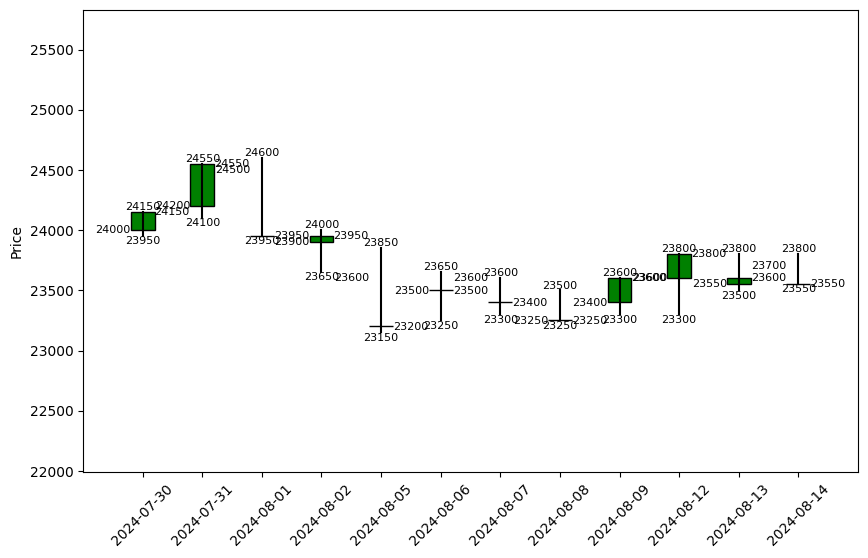

[{'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '30/07/2024', 'Time': None, 'Open': '24000', 'High': '24150', 'Low': '23950', 'Close': '24150', 'Volume': '5489200', 'Value': '131998999999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '31/07/2024', 'Time': None, 'Open': '24200', 'High': '24550', 'Low': '24100', 'Close': '24550', 'Volume': '8548700', 'Value': '208478694999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '01/08/2024', 'Time': None, 'Open': '24500', 'High': '24600', 'Low': '23950', 'Close': '23950', 'Volume': '9174700', 'Value': '221875354999.9970'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '02/08/2024', 'Time': None, 'Open': '23900', 'High': '24000', 'Low': '23650', 'Close': '23950', 'Volume': '13706000', 'Value': '326483410000'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '05/08/2024', 'Time': None, 'Open': '23600', 'High': '23850', 'Low': '23150', 'Close': '23200', 'Volume': '20086500', 'Value': '471876965000.0060'}, {'Symbo

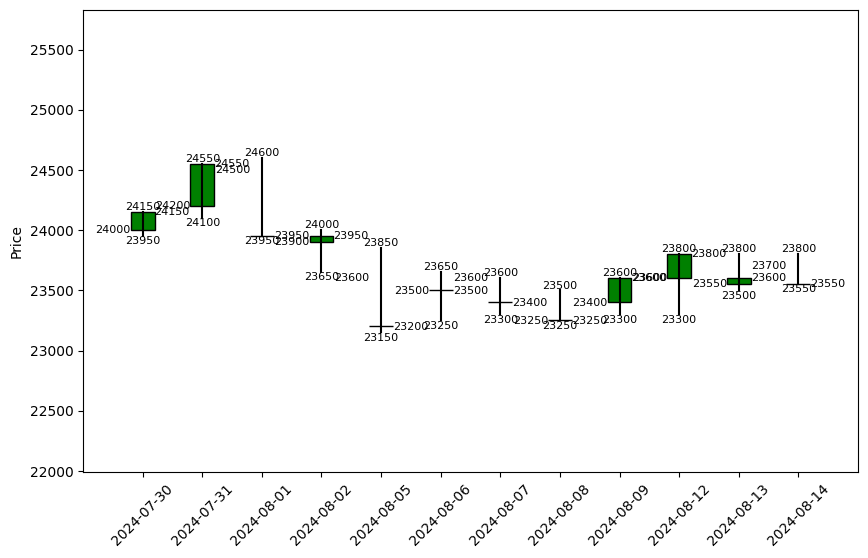

[{'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '30/07/2024', 'Time': None, 'Open': '24000', 'High': '24150', 'Low': '23950', 'Close': '24150', 'Volume': '5489200', 'Value': '131998999999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '31/07/2024', 'Time': None, 'Open': '24200', 'High': '24550', 'Low': '24100', 'Close': '24550', 'Volume': '8548700', 'Value': '208478694999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '01/08/2024', 'Time': None, 'Open': '24500', 'High': '24600', 'Low': '23950', 'Close': '23950', 'Volume': '9174700', 'Value': '221875354999.9970'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '02/08/2024', 'Time': None, 'Open': '23900', 'High': '24000', 'Low': '23650', 'Close': '23950', 'Volume': '13706000', 'Value': '326483410000'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '05/08/2024', 'Time': None, 'Open': '23600', 'High': '23850', 'Low': '23150', 'Close': '23200', 'Volume': '20086500', 'Value': '471876965000.0060'}, {'Symbo

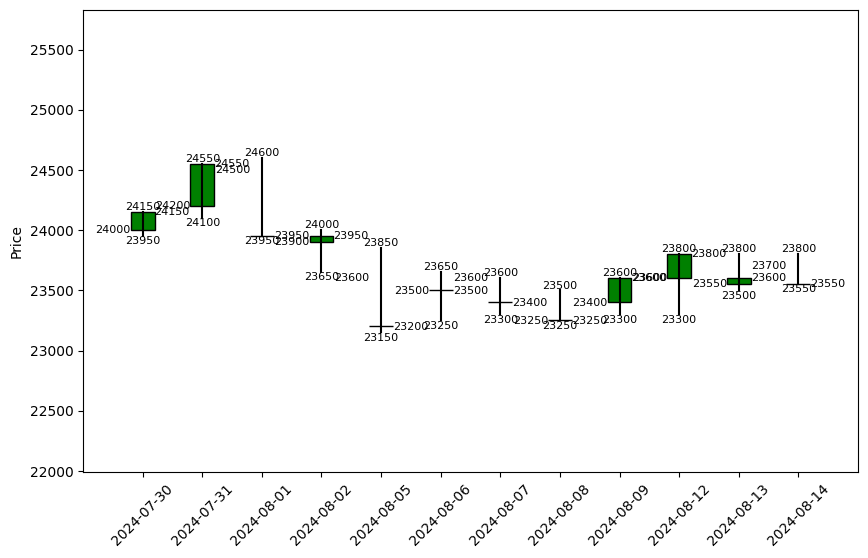

[{'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '30/07/2024', 'Time': None, 'Open': '24000', 'High': '24150', 'Low': '23950', 'Close': '24150', 'Volume': '5489200', 'Value': '131998999999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '31/07/2024', 'Time': None, 'Open': '24200', 'High': '24550', 'Low': '24100', 'Close': '24550', 'Volume': '8548700', 'Value': '208478694999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '01/08/2024', 'Time': None, 'Open': '24500', 'High': '24600', 'Low': '23950', 'Close': '23950', 'Volume': '9174700', 'Value': '221875354999.9970'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '02/08/2024', 'Time': None, 'Open': '23900', 'High': '24000', 'Low': '23650', 'Close': '23950', 'Volume': '13706000', 'Value': '326483410000'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '05/08/2024', 'Time': None, 'Open': '23600', 'High': '23850', 'Low': '23150', 'Close': '23200', 'Volume': '20086500', 'Value': '471876965000.0060'}, {'Symbo

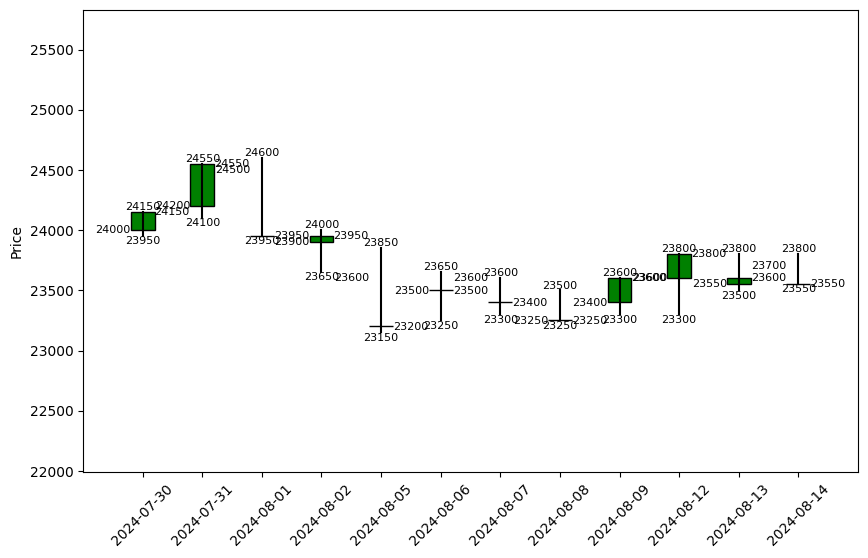

[{'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '30/07/2024', 'Time': None, 'Open': '24000', 'High': '24150', 'Low': '23950', 'Close': '24150', 'Volume': '5489200', 'Value': '131998999999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '31/07/2024', 'Time': None, 'Open': '24200', 'High': '24550', 'Low': '24100', 'Close': '24550', 'Volume': '8548700', 'Value': '208478694999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '01/08/2024', 'Time': None, 'Open': '24500', 'High': '24600', 'Low': '23950', 'Close': '23950', 'Volume': '9174700', 'Value': '221875354999.9970'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '02/08/2024', 'Time': None, 'Open': '23900', 'High': '24000', 'Low': '23650', 'Close': '23950', 'Volume': '13706000', 'Value': '326483410000'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '05/08/2024', 'Time': None, 'Open': '23600', 'High': '23850', 'Low': '23150', 'Close': '23200', 'Volume': '20086500', 'Value': '471876965000.0060'}, {'Symbo

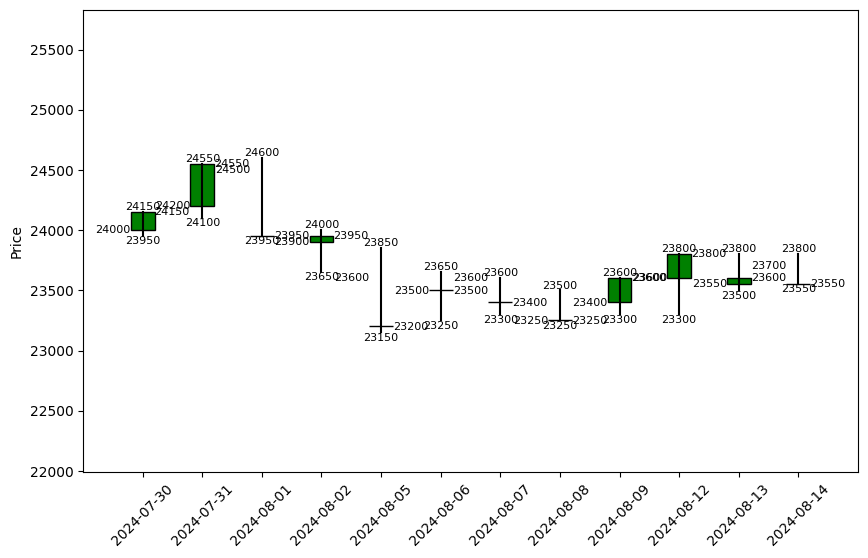

[{'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '30/07/2024', 'Time': None, 'Open': '24000', 'High': '24150', 'Low': '23950', 'Close': '24150', 'Volume': '5489200', 'Value': '131998999999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '31/07/2024', 'Time': None, 'Open': '24200', 'High': '24550', 'Low': '24100', 'Close': '24550', 'Volume': '8548700', 'Value': '208478694999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '01/08/2024', 'Time': None, 'Open': '24500', 'High': '24600', 'Low': '23950', 'Close': '23950', 'Volume': '9174700', 'Value': '221875354999.9970'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '02/08/2024', 'Time': None, 'Open': '23900', 'High': '24000', 'Low': '23650', 'Close': '23950', 'Volume': '13706000', 'Value': '326483410000'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '05/08/2024', 'Time': None, 'Open': '23600', 'High': '23850', 'Low': '23150', 'Close': '23200', 'Volume': '20086500', 'Value': '471876965000.0060'}, {'Symbo

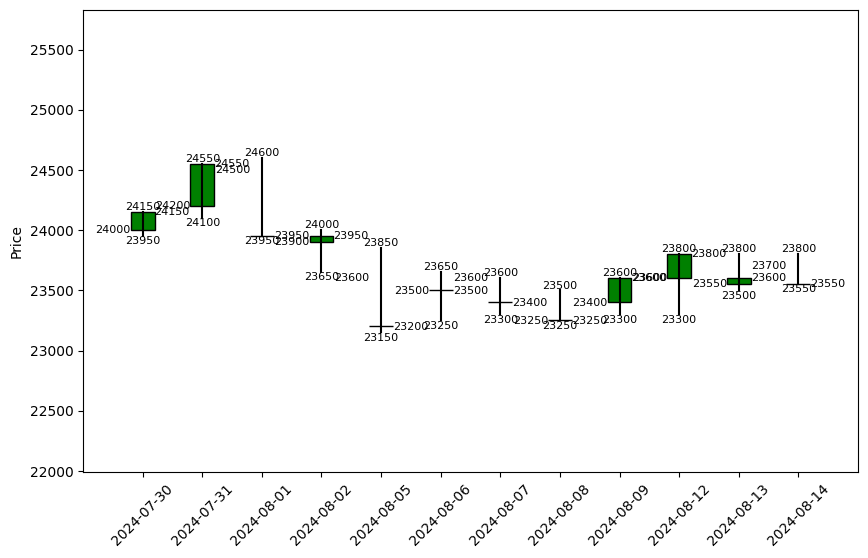

[{'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '30/07/2024', 'Time': None, 'Open': '24000', 'High': '24150', 'Low': '23950', 'Close': '24150', 'Volume': '5489200', 'Value': '131998999999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '31/07/2024', 'Time': None, 'Open': '24200', 'High': '24550', 'Low': '24100', 'Close': '24550', 'Volume': '8548700', 'Value': '208478694999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '01/08/2024', 'Time': None, 'Open': '24500', 'High': '24600', 'Low': '23950', 'Close': '23950', 'Volume': '9174700', 'Value': '221875354999.9970'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '02/08/2024', 'Time': None, 'Open': '23900', 'High': '24000', 'Low': '23650', 'Close': '23950', 'Volume': '13706000', 'Value': '326483410000'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '05/08/2024', 'Time': None, 'Open': '23600', 'High': '23850', 'Low': '23150', 'Close': '23200', 'Volume': '20086500', 'Value': '471876965000.0060'}, {'Symbo

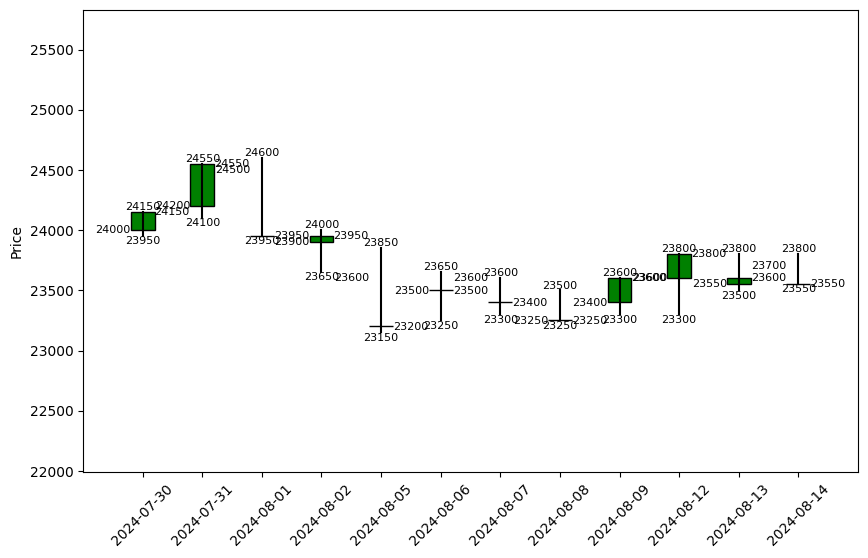

[{'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '30/07/2024', 'Time': None, 'Open': '24000', 'High': '24150', 'Low': '23950', 'Close': '24150', 'Volume': '5489200', 'Value': '131998999999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '31/07/2024', 'Time': None, 'Open': '24200', 'High': '24550', 'Low': '24100', 'Close': '24550', 'Volume': '8548700', 'Value': '208478694999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '01/08/2024', 'Time': None, 'Open': '24500', 'High': '24600', 'Low': '23950', 'Close': '23950', 'Volume': '9174700', 'Value': '221875354999.9970'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '02/08/2024', 'Time': None, 'Open': '23900', 'High': '24000', 'Low': '23650', 'Close': '23950', 'Volume': '13706000', 'Value': '326483410000'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '05/08/2024', 'Time': None, 'Open': '23600', 'High': '23850', 'Low': '23150', 'Close': '23200', 'Volume': '20086500', 'Value': '471876965000.0060'}, {'Symbo

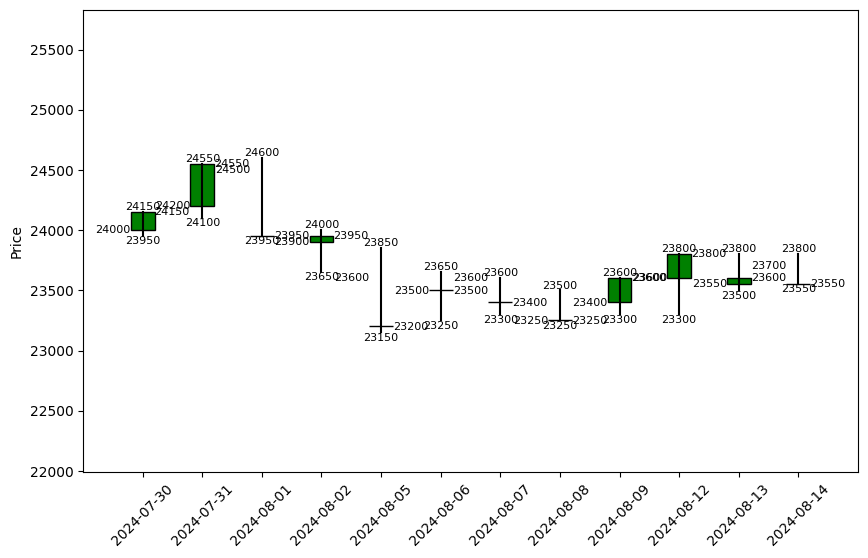

[{'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '30/07/2024', 'Time': None, 'Open': '24000', 'High': '24150', 'Low': '23950', 'Close': '24150', 'Volume': '5489200', 'Value': '131998999999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '31/07/2024', 'Time': None, 'Open': '24200', 'High': '24550', 'Low': '24100', 'Close': '24550', 'Volume': '8548700', 'Value': '208478694999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '01/08/2024', 'Time': None, 'Open': '24500', 'High': '24600', 'Low': '23950', 'Close': '23950', 'Volume': '9174700', 'Value': '221875354999.9970'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '02/08/2024', 'Time': None, 'Open': '23900', 'High': '24000', 'Low': '23650', 'Close': '23950', 'Volume': '13706000', 'Value': '326483410000'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '05/08/2024', 'Time': None, 'Open': '23600', 'High': '23850', 'Low': '23150', 'Close': '23200', 'Volume': '20086500', 'Value': '471876965000.0060'}, {'Symbo

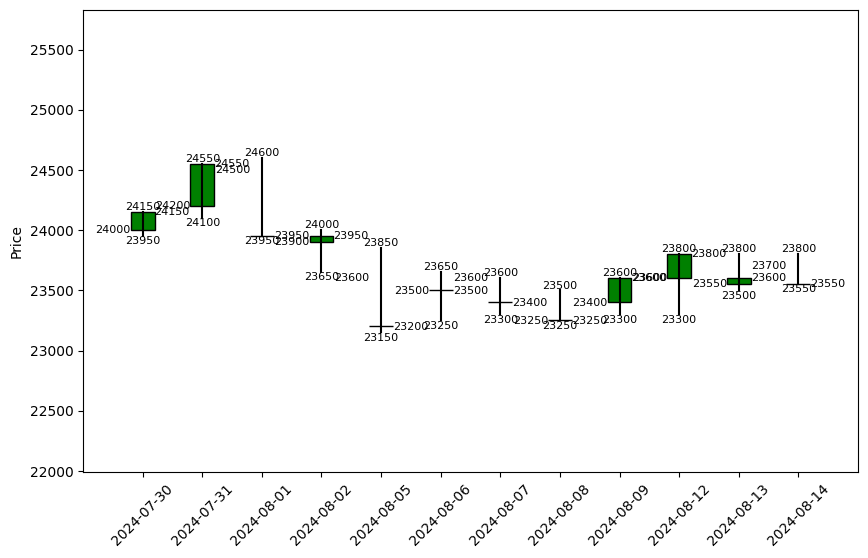

[{'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '30/07/2024', 'Time': None, 'Open': '24000', 'High': '24150', 'Low': '23950', 'Close': '24150', 'Volume': '5489200', 'Value': '131998999999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '31/07/2024', 'Time': None, 'Open': '24200', 'High': '24550', 'Low': '24100', 'Close': '24550', 'Volume': '8548700', 'Value': '208478694999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '01/08/2024', 'Time': None, 'Open': '24500', 'High': '24600', 'Low': '23950', 'Close': '23950', 'Volume': '9174700', 'Value': '221875354999.9970'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '02/08/2024', 'Time': None, 'Open': '23900', 'High': '24000', 'Low': '23650', 'Close': '23950', 'Volume': '13706000', 'Value': '326483410000'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '05/08/2024', 'Time': None, 'Open': '23600', 'High': '23850', 'Low': '23150', 'Close': '23200', 'Volume': '20086500', 'Value': '471876965000.0060'}, {'Symbo

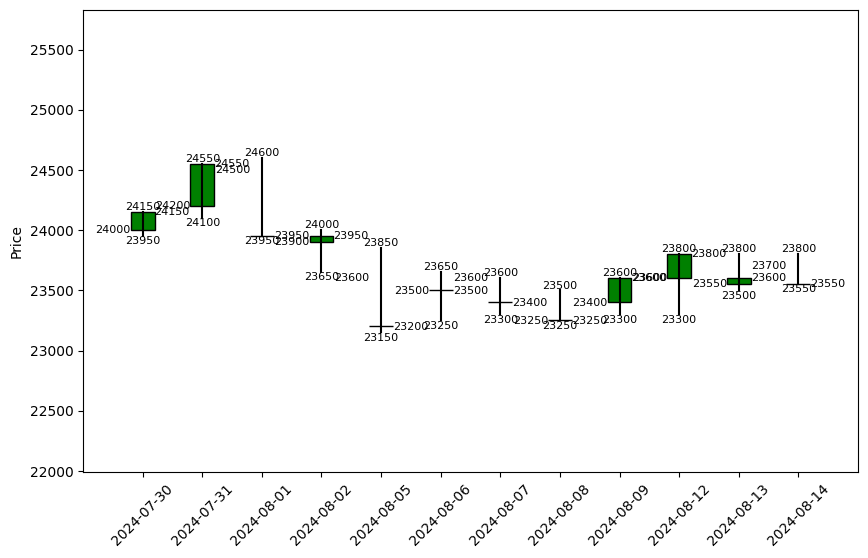

[{'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '30/07/2024', 'Time': None, 'Open': '24000', 'High': '24150', 'Low': '23950', 'Close': '24150', 'Volume': '5489200', 'Value': '131998999999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '31/07/2024', 'Time': None, 'Open': '24200', 'High': '24550', 'Low': '24100', 'Close': '24550', 'Volume': '8548700', 'Value': '208478694999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '01/08/2024', 'Time': None, 'Open': '24500', 'High': '24600', 'Low': '23950', 'Close': '23950', 'Volume': '9174700', 'Value': '221875354999.9970'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '02/08/2024', 'Time': None, 'Open': '23900', 'High': '24000', 'Low': '23650', 'Close': '23950', 'Volume': '13706000', 'Value': '326483410000'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '05/08/2024', 'Time': None, 'Open': '23600', 'High': '23850', 'Low': '23150', 'Close': '23200', 'Volume': '20086500', 'Value': '471876965000.0060'}, {'Symbo

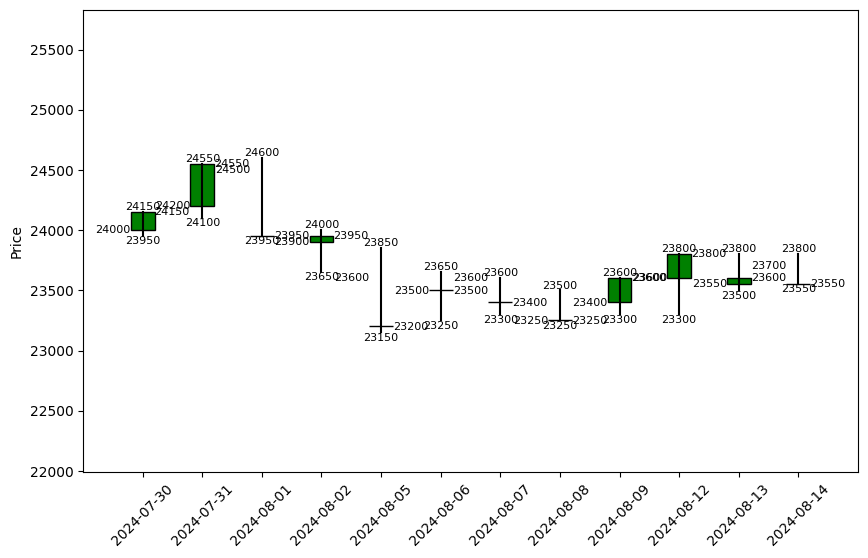

[{'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '30/07/2024', 'Time': None, 'Open': '24000', 'High': '24150', 'Low': '23950', 'Close': '24150', 'Volume': '5489200', 'Value': '131998999999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '31/07/2024', 'Time': None, 'Open': '24200', 'High': '24550', 'Low': '24100', 'Close': '24550', 'Volume': '8548700', 'Value': '208478694999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '01/08/2024', 'Time': None, 'Open': '24500', 'High': '24600', 'Low': '23950', 'Close': '23950', 'Volume': '9174700', 'Value': '221875354999.9970'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '02/08/2024', 'Time': None, 'Open': '23900', 'High': '24000', 'Low': '23650', 'Close': '23950', 'Volume': '13706000', 'Value': '326483410000'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '05/08/2024', 'Time': None, 'Open': '23600', 'High': '23850', 'Low': '23150', 'Close': '23200', 'Volume': '20086500', 'Value': '471876965000.0060'}, {'Symbo

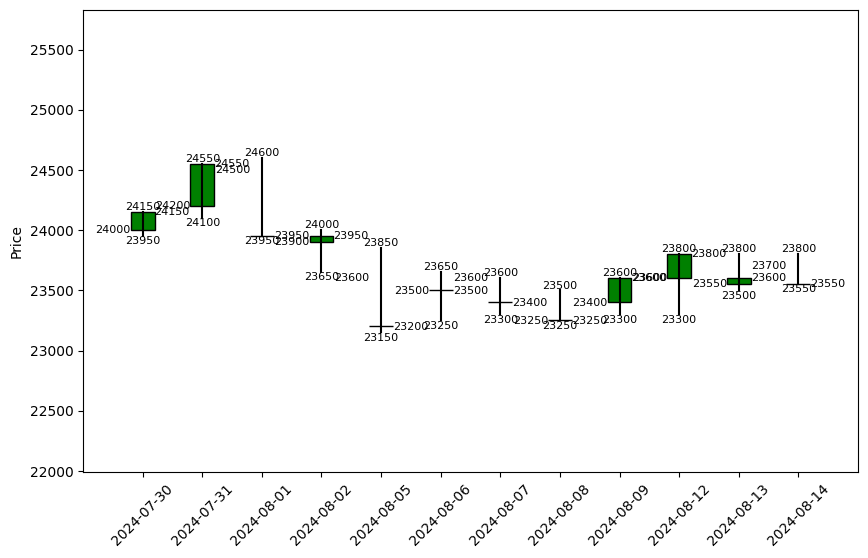

[{'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '30/07/2024', 'Time': None, 'Open': '24000', 'High': '24150', 'Low': '23950', 'Close': '24150', 'Volume': '5489200', 'Value': '131998999999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '31/07/2024', 'Time': None, 'Open': '24200', 'High': '24550', 'Low': '24100', 'Close': '24550', 'Volume': '8548700', 'Value': '208478694999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '01/08/2024', 'Time': None, 'Open': '24500', 'High': '24600', 'Low': '23950', 'Close': '23950', 'Volume': '9174700', 'Value': '221875354999.9970'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '02/08/2024', 'Time': None, 'Open': '23900', 'High': '24000', 'Low': '23650', 'Close': '23950', 'Volume': '13706000', 'Value': '326483410000'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '05/08/2024', 'Time': None, 'Open': '23600', 'High': '23850', 'Low': '23150', 'Close': '23200', 'Volume': '20086500', 'Value': '471876965000.0060'}, {'Symbo

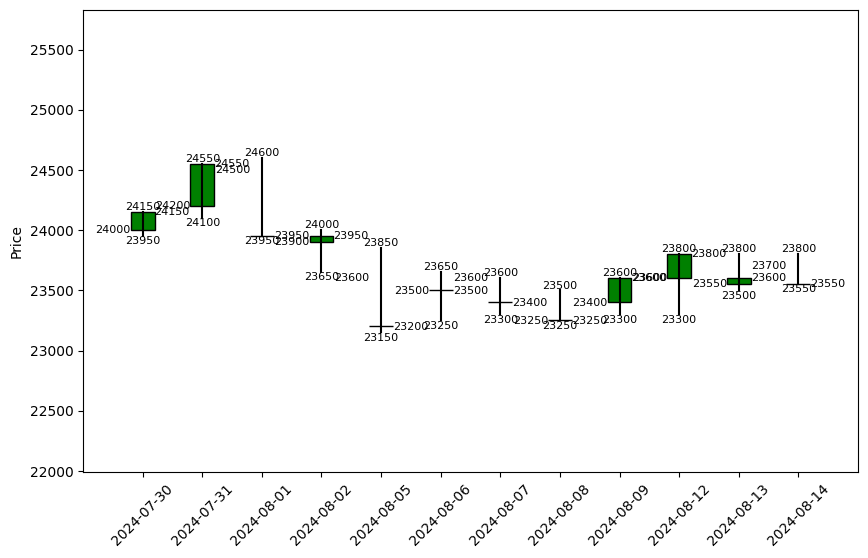

[{'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '30/07/2024', 'Time': None, 'Open': '24000', 'High': '24150', 'Low': '23950', 'Close': '24150', 'Volume': '5489200', 'Value': '131998999999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '31/07/2024', 'Time': None, 'Open': '24200', 'High': '24550', 'Low': '24100', 'Close': '24550', 'Volume': '8548700', 'Value': '208478694999.9990'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '01/08/2024', 'Time': None, 'Open': '24500', 'High': '24600', 'Low': '23950', 'Close': '23950', 'Volume': '9174700', 'Value': '221875354999.9970'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '02/08/2024', 'Time': None, 'Open': '23900', 'High': '24000', 'Low': '23650', 'Close': '23950', 'Volume': '13706000', 'Value': '326483410000'}, {'Symbol': 'ACB', 'Market': 'HOSE', 'TradingDate': '05/08/2024', 'Time': None, 'Open': '23600', 'High': '23850', 'Low': '23150', 'Close': '23200', 'Volume': '20086500', 'Value': '471876965000.0060'}, {'Symbo

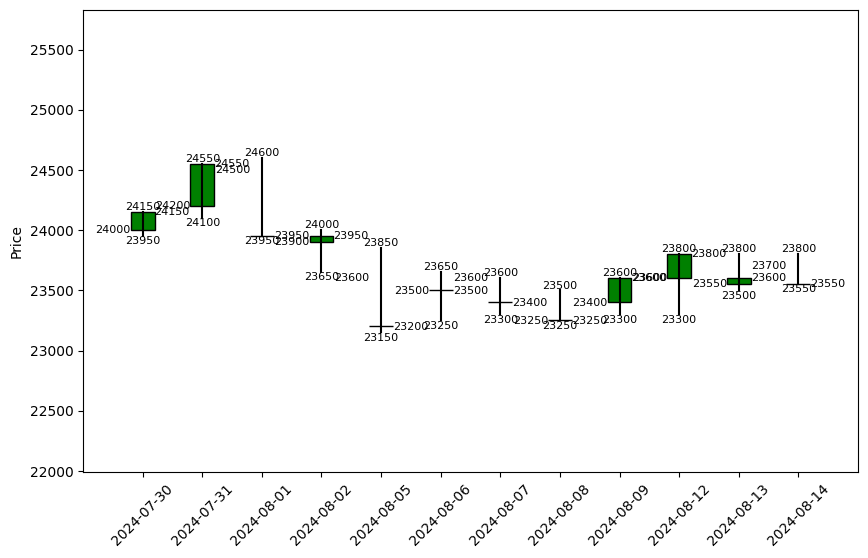

: 

In [8]:
import schedule
import time
from datetime import datetime, timedelta

def execute_trade():
    end_date = datetime.now() # Lấy ngày hiện tại
    start_date = end_date - timedelta(days=15)  # Lấy ngày trước ngày hiện tại

    # Định dạng ngày tháng theo chuẩn (ví dụ: "16-11-2023")
    start_date_str = start_date.strftime("%d/%m/%Y")
    end_date_str = end_date.strftime("%d/%m/%Y")

    data = loaddata('ACB', start_date_str, end_date_str)
    # print(data)
    kiemtratinhieu(data, start_date_str, end_date_str)

    showdata(data)

# Lên lịch hàm execute_trade để chạy mỗi phút
# schedule.every(1).minute.do(execute_trade)
schedule.every(1).minute.do(execute_trade)

while True:
    schedule.run_pending()  # Kiểm tra và thực hiện các công việc lên lịch
    time.sleep(1)